# Jnkep minimizer fit

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from scipy.stats import norm
import matplotlib
import pandas as pd 
import jax.numpy as jnp
from jax import config, random
import numpyro, jax
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, init_to_value
config.update('jax_enable_x64', True)
numpyro.set_platform('cpu') 
num_chains = 4
numpyro.set_host_device_count(num_chains)
print ('# jax device count:', jax.local_device_count())

from jnkepler.jaxttv import JaxTTV
from jnkepler.jaxttv import ttv_default_parameter_bounds, ttv_optim_curve_fit, scale_pdic
import corner

TESS_offset = 2457000

# jax device count: 4


In [18]:
bootstrap = True

# data

In [19]:
### Read results
d = pd.read_csv("toi_1339_transit_data_all_planets.txt", sep="\s+", header=0, names=['Planet_num', 'Index', 'Tc', 'Tc_err'])
# d = pd.read_csv("toi_1339_transit_data_all.txt", sep="\s+", header=0, names=['Planet_num', 'Index', 'Tc', 'Tc_err'])

print(d)

     Planet_num  Index           Tc    Tc_err
0             1      0  1715.354909  0.001073
1             1      2  1733.115586  0.001797
2             1      3  1741.996174  0.001416
3             1      5  1759.758648  0.001363
4             1      6  1768.637415  0.003105
..          ...    ...          ...       ...
106           3     42  3354.303788  0.002451
107           3     43  3392.661021  0.001888
108           3     47  3546.072794  0.001416
109           3     49  3622.770169  0.001992
110           3     50  3661.127060  0.002638

[111 rows x 4 columns]


<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_9452/4101420919.py:2: SyntaxWarning: invalid escape sequence '\s'
  d = pd.read_csv("toi_1339_transit_data_all_planets.txt", sep="\s+", header=0, names=['Planet_num', 'Index', 'Tc', 'Tc_err'])


In [20]:
### get times, errs from the data
list_of_obs_transit_times = []
list_of_transit_time_errs = []

period_guess = [8.8803232, 28.579657965796578, 38.35013501350135]#, 101.12]
# period_guess = [8.8803232, 28.579657965796578, 38.35013501350135, 101.12]

for j in range(3):
    list_of_obs_transit_times.append(np.array(d.Tc[d.Planet_num==j+1]))
    list_of_transit_time_errs.append(np.array(d.Tc_err[d.Planet_num==j+1]))
# index_obs_1 = np.array(d.Index[d.Planet_num==1])
index_obs_1 = np.array(d.Index[d.Planet_num==1])
index_obs_2 = np.array(d.Index[d.Planet_num==2])
index_obs_3 = np.array(d.Index[d.Planet_num==3])



tcobs = []
errorobs = []
for j in range(3):
    tcobs.append(np.array(d.Tc[d.Planet_num == j + 1]))
    errorobs.append(np.array(d.Tc_err[d.Planet_num == j + 1]))

# tcobs.append(np.array([1715.1]))
# errorobs.append(np.array([1e3]))

print(tcobs)
print(tcobs[1][0])

[array([1715.3549092 , 1733.11558647, 1741.99617437, 1759.75864806,
       1768.63741504, 1786.39893646, 1795.28264125, 1804.15975377,
       1813.0433371 , 1821.91789761, 1830.80156766, 1839.68065239,
       1875.20165235, 1892.96274789, 1901.84315893, 1910.72219763,
       1919.60164891, 1964.00366294, 1972.88406769, 1981.7648828 ,
       1990.64477483, 1999.5245227 , 2008.40545702, 2425.78171907,
       2434.66251826, 2443.54276122, 2621.15109341, 2630.02758785,
       2647.79010188, 2656.66944084, 2701.07258937, 2718.83240221,
       2727.71128911, 2736.5922973 , 2798.75435848, 2807.63571139,
       2816.51470333, 2825.39591176, 2834.27786631, 2843.15668893,
       2852.03782905, 2914.19776581, 2923.07769861, 2931.9575024 ,
       2940.83973704, 2949.72029012, 2958.60155892, 3296.05116921,
       3340.45425494, 3349.33440094, 3358.21289422, 3367.09919651,
       3375.97472681, 3384.85472898, 3393.73810221, 3402.61748567,
       3420.37703733, 3438.13702439, 3447.01865068, 3455.8988

In [21]:
### run JaxTTV sim
t_start = 1715.  # start of integration
# t_end = 5500. # end of integration
t_end = 3670.
dt = 0.1 # integration timestep
# jttv = JaxTTV(t_start, t_end, dt, list_of_obs_transit_times, period_guess, errorobs=list_of_transit_time_errs)


# fixed_jitter = 5 / (60 * 24)  # 5 minutes in days

# # Assuming errorobs is a list of arrays per planet:
# errorobs_with_jitter = []
# for e in errorobs:
#     e_array = np.array(e)
#     e_with_jitter = np.sqrt(e_array**2 + fixed_jitter**2)
#     errorobs_with_jitter.append(e_with_jitter)
# jttv = JaxTTV(t_start, t_end, dt, tcobs, period_guess, errorobs=errorobs_with_jitter, print_info=True)

jttv = JaxTTV(t_start, t_end, dt, tcobs, period_guess, errorobs=errorobs, print_info=True)


# number of transiting planets:    3
# integration starts at:           1715.00
# first transit time in data:      1715.35
# last transit time in data:       3661.13
# integration ends at:             3670.00
# integration time step:           0.1000 (1/88 of innermost period)



In [22]:
### make own param bounds to include i?

In [23]:
### set bounds for fit
param_bounds = ttv_default_parameter_bounds(jttv, emax=0.5)

### initialize p_init: p1,p2,ecosw1,ecosw2,esinw1,esinw2,tic1,tic2,lnpmass1,lnpmass2
### using best fit for run with all points
# p_init = np.array([8.8803232, 28.579657965796578, 38.35013501350135, 
#                    -0.21369753, -0.21369753, -0.18361236, 
#                    -0.23016884, -0.23016884, -0.19734158, 
#                    1715.3549092, 1726.05430737, 1743.55228223, 
#                    -10.9106092, -10.97106092, -11.30491702])

p_init = np.array([8.88019411, 28.58459538, 38.35697941,
                   -0.01057476, -0.17055918, -0.14674058,
                   -0.04431811, -0.19846304, -0.17068143,
                   1715.35556381, 1726.05575, 1743.55759245,
                   -9.12784028, -11.19145558, -11.67248425])

# p_init = np.array([8.88019411, 28.58459538, 38.35697941, 101.12
#                    -0.01057476, -0.17055918, -0.14674058, 0.,
#                    -0.04431811, -0.19846304, -0.17068143, 0.,
#                    1715.35556381, 1726.05575, 1743.55759245, 1800.,
#                    -9.12784028, -11.19145558, -11.67248425, -4.1])


### fit
popt = ttv_optim_curve_fit(jttv,param_bounds,p_init=p_init, plot=False)
# plt.show()
print(popt)

/opt/homebrew/anaconda3/lib/python3.12/site-packages/jnkepler/jaxttv/infer.py:97: UserWarning: Bounds for cosi/lnode not provided: assuming coplanar orbits.
  warnings.warn(


# running least squares optimization...
# objective function: 148.75 --> 148.75 (111 data)
# elapsed time: 1.4 sec
{'period': array([ 8.88019411, 28.58459538, 38.35697941]), 'ecosw': array([-0.01057476, -0.17055918, -0.14674058]), 'esinw': array([-0.04431811, -0.19846304, -0.17068143]), 'tic': array([1715.35556381, 1726.05575   , 1743.55759245]), 'lnpmass': array([ -9.12784028, -11.19145558, -11.67248425]), 'pmass': Array([1.08599877e-04, 1.37915347e-05, 8.52519851e-06], dtype=float64)}


In [24]:
print(1.98921496e-05* 3e5)
print(1.16917195e-05* 3e5)


5.96764488
3.50751585


/opt/homebrew/anaconda3/lib/python3.12/site-packages/jnkepler/jaxttv/jaxttv.py:523: UserWarning: using t0 and P from a linear fit to the observed transit times.
  warnings.warn(


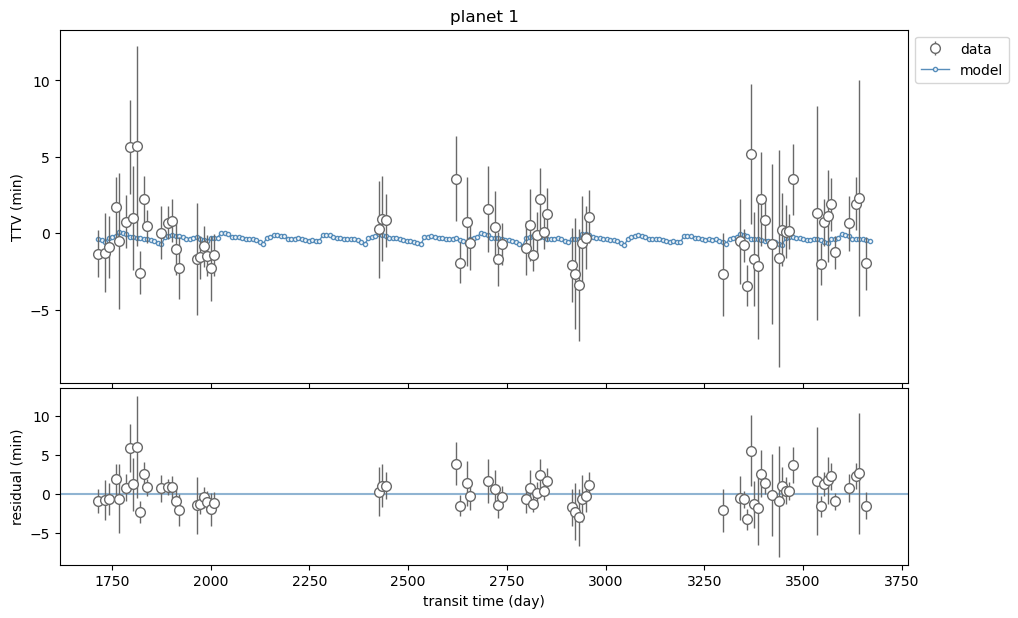

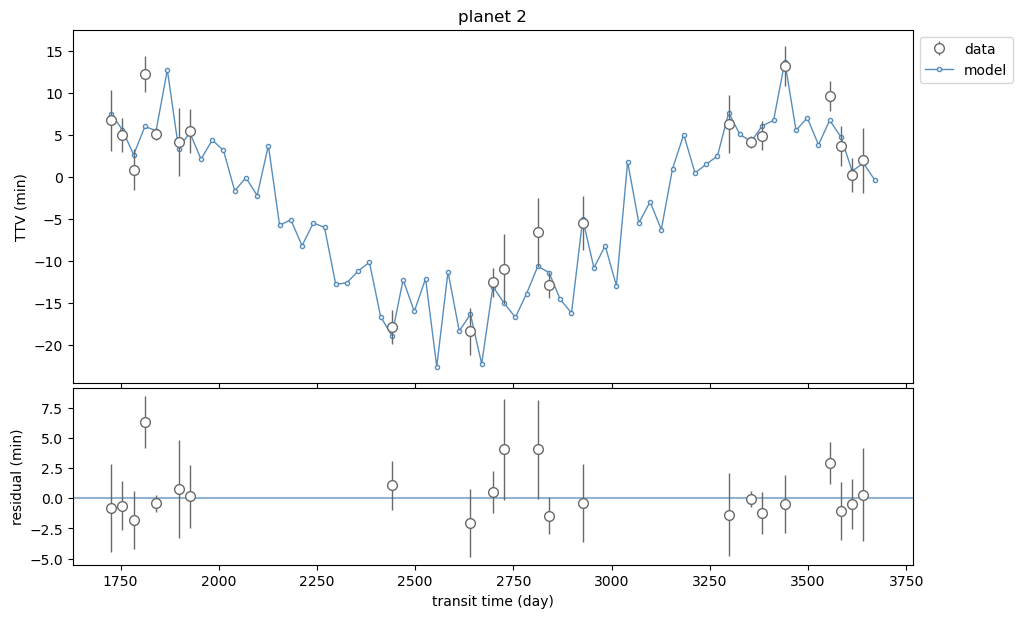

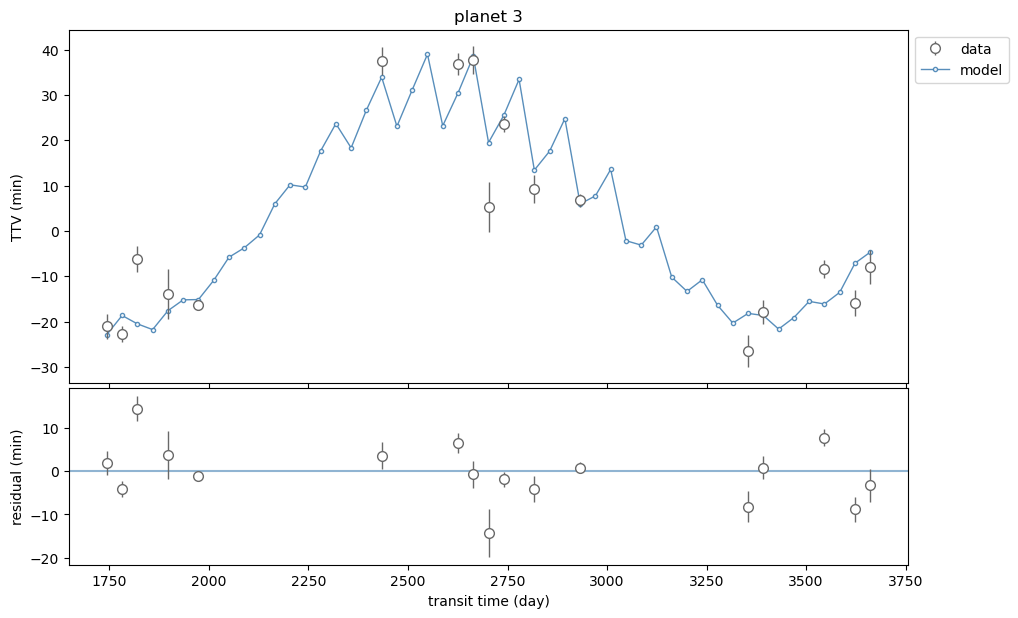

In [25]:
### plot fit
tcall = jttv.get_transit_times_all_list(popt,truncate=False)
jttv.plot_model(tcall, marker='.')
plt.show()

# fractional energy error (symplectic, dt=1.00e-01): 1.11e-11
# fractional energy error (symplectic, dt=8.88e-03): 1.20e-12
# max difference in tc: 4.19e-06 days (0.36 sec)


sample: 100%|█| 1000/1000 [00:00<00:00, 1925.92it/s, 7 steps of size 5.67e-01. a



                mean       std    median      5.0%     95.0%     n_eff     r_hat
      lndf      1.45      0.43      1.39      0.88      2.15    180.60      1.00
     lnvar     -0.38      0.24     -0.37     -0.81     -0.01    193.98      1.00

Number of divergences: 0


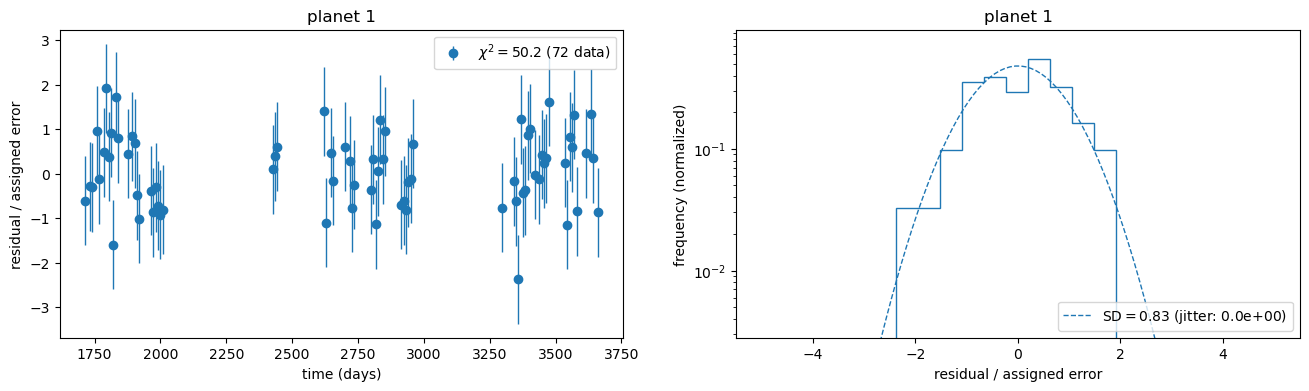

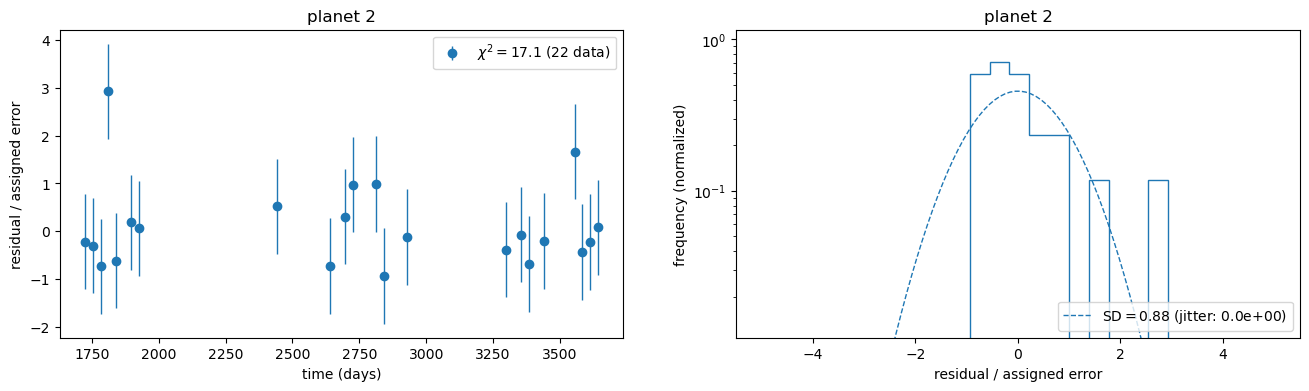

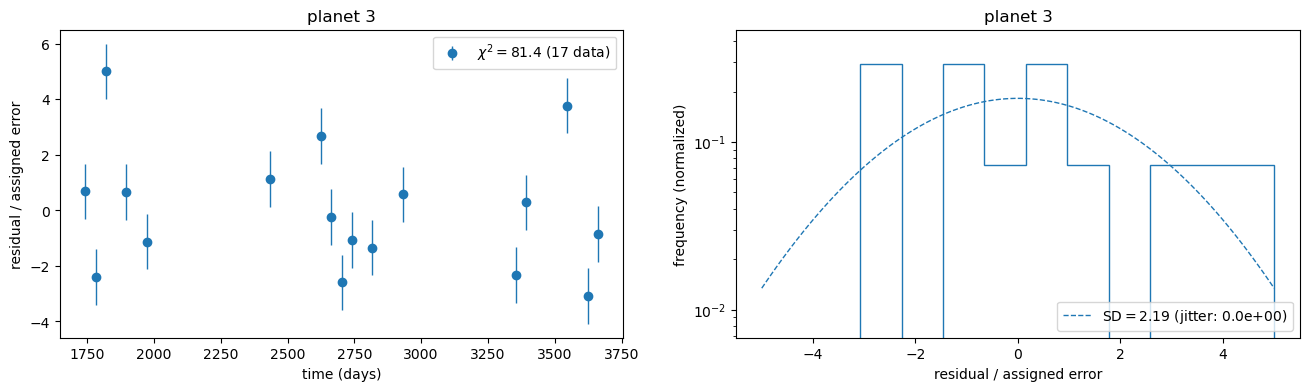

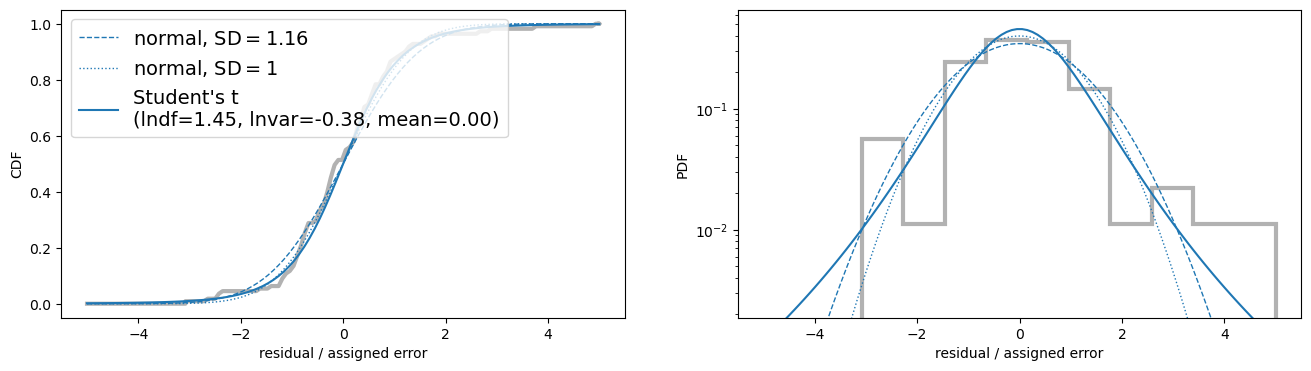

In [26]:
### check precision and residuals 
tc, _ = jttv.check_timing_precision(popt)
jitter = 5 / (24*60)
jitters = [jitter, jitter]
pdic_normal, pdic_student = jttv.check_residuals(popt)
plt.show()

In [27]:
print(pdic_normal)
print(pdic_student)

{'mean': Array(0.00015029, dtype=float64), 'sd': Array(0.00218879, dtype=float64)}
{'lndf_loc': Array(1.44679925, dtype=float64), 'lndf_scale': Array(0.4284468, dtype=float64), 'lnvar_loc': Array(-0.38198365, dtype=float64), 'lnvar_scale': Array(0.24133659, dtype=float64)}


In [30]:
### compute RMS and chisq residuals 
from scipy.spatial import cKDTree

# Helper to match model times to observed times using a KDTree (fast nearest neighbor search)
def match_model_to_obs(model_times, obs_times):
    tree = cKDTree(model_times[:, None])
    dists, indices = tree.query(obs_times[:, None])
    return model_times[indices]

# Get full predicted transit times
tmodel_all = jttv.get_transit_times_all_list(popt, truncate=False)

# Match model to observed times
model_at_obs_2 = match_model_to_obs(tmodel_all[0], tcobs[0])
model_at_obs_3 = match_model_to_obs(tmodel_all[1], tcobs[1])

# Compute residuals
residuals_2 = tcobs[0] - model_at_obs_2
residuals_3 = tcobs[1] - model_at_obs_3

# RMS in minutes
rms_2 = np.sqrt(np.mean(residuals_2**2)) * 24 * 60
rms_3 = np.sqrt(np.mean(residuals_3**2)) * 24 * 60

# Combine for chi-squared
all_obs = np.concatenate([tcobs[0], tcobs[1]])
all_model = np.concatenate([model_at_obs_3, model_at_obs_2])
all_errs = np.concatenate([errorobs[0], errorobs[1]])

# Chi-squared
N = len(all_obs)
k = len(popt)
chi2 = np.sum(((all_obs - all_model) / all_errs)**2)
chi2_red = chi2 / (N - k)

# Print nicely
print(f"RMS residuals: Planet 2 = {rms_2:.2f} min, Planet 3 = {rms_3:.2f} min")
print(f"Reduced chi-squared: {chi2_red:.2f}")


RMS residuals: Planet 2 = 1.95 min, Planet 3 = 2.12 min
Reduced chi-squared: 624285507444.56


In [31]:
# Extract best-fit parameters
best_fit_period_2 = popt['period'][1]
best_fit_period_3 = popt['period'][2]
best_fit_tc_2 = popt['tic'][1]
best_fit_tc_3 = popt['tic'][2]

# Get observed times and errors
t_obs_2 = tcobs[1]
t_obs_3 = tcobs[2]
t_err_2 = errorobs[1]
t_err_3 = errorobs[2]


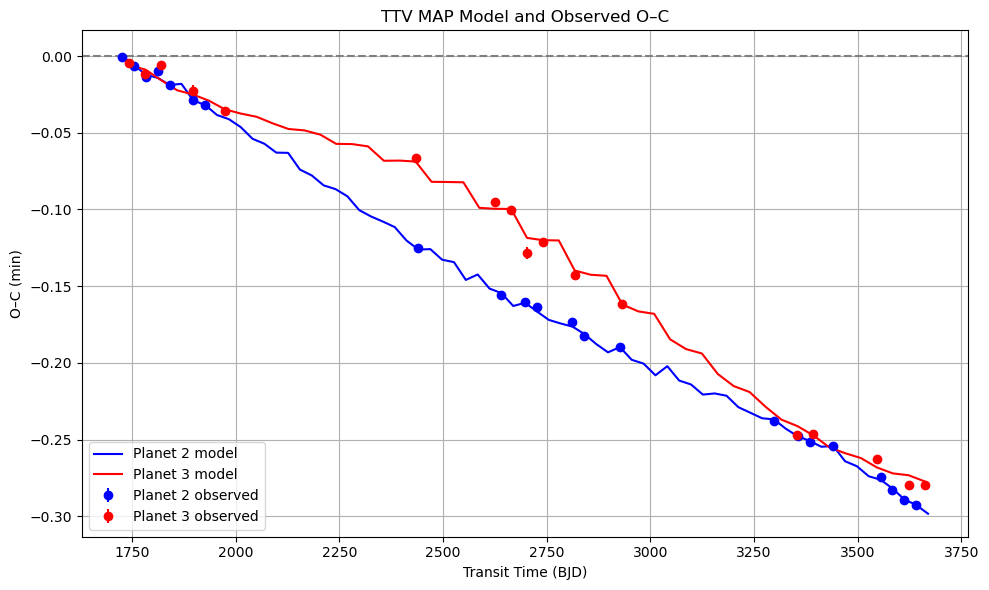

In [35]:

# Get full model-predicted transit times from JaxTTV
tmodel_2 = tmodel_all[1]  # Planet 2
tmodel_3 = tmodel_all[2]  # Planet 3

# Indices (epochs) for the full model
epochs_2 = np.arange(len(tmodel_2))
epochs_3 = np.arange(len(tmodel_3))

# Linear ephemeris from best-fit periods and Tc
ephem_2 = best_fit_tc_2 + best_fit_period_2 * epochs_2
ephem_3 = best_fit_tc_3 + best_fit_period_3 * epochs_3

# Full model O–C in minutes
model_omc_2 = (tmodel_2 - ephem_2) 
model_omc_3 = (tmodel_3 - ephem_3) 

# Observed O–C in minutes
obs_epochs_2 = index_obs_2  # assumed available
obs_epochs_3 = index_obs_3
obs_ephem_2 = best_fit_tc_2 + best_fit_period_2 * obs_epochs_2
obs_ephem_3 = best_fit_tc_3 + best_fit_period_3 * obs_epochs_3
obs_omc_2 = (tcobs[1] - obs_ephem_2) 
obs_omc_3 = (tcobs[2] - obs_ephem_3) 


# Plot O–C (Model Curve + Observed)
plt.figure(figsize=(10, 6))

# Model TTV curves
plt.plot(tmodel_2, model_omc_2, 'b-', label='Planet 2 model')
plt.plot(tmodel_3, model_omc_3, 'r-', label='Planet 3 model')

# Observed TTV points
plt.errorbar(tcobs[1], obs_omc_2, yerr=errorobs[1], fmt='bo', label='Planet 2 observed')
plt.errorbar(tcobs[2], obs_omc_3, yerr=errorobs[2], fmt='ro', label='Planet 3 observed')

plt.axhline(0, color='gray', linestyle='--')
plt.xlabel("Transit Time (BJD)")
plt.ylabel("O–C (min)")
plt.title("TTV MAP Model and Observed O–C")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


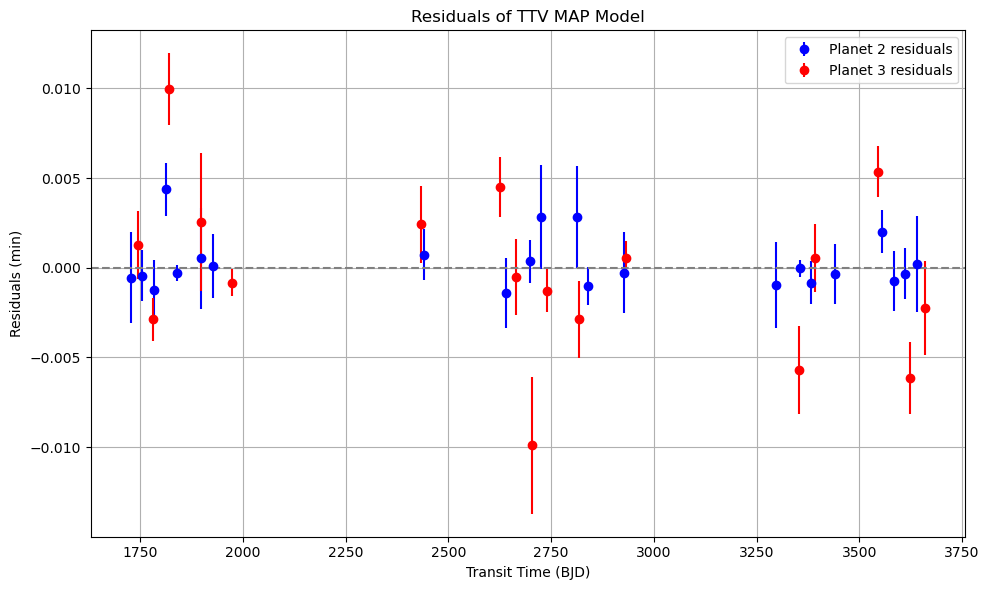

In [36]:
# Get model O–C at observed epochs
model_omc_obs_2 = model_omc_2[index_obs_2]
model_omc_obs_3 = model_omc_3[index_obs_3]

# Calculate residuals (observed - model at observed points)
residuals_2 = obs_omc_2 - model_omc_obs_2
residuals_3 = obs_omc_3 - model_omc_obs_3
# Plot residuals
plt.figure(figsize=(10, 6))

# Residuals for Planet 2
plt.errorbar(tcobs[1], residuals_2, yerr=errorobs[1], fmt='bo', label='Planet 2 residuals')

# Residuals for Planet 3
plt.errorbar(tcobs[2], residuals_3, yerr=errorobs[2], fmt='ro', label='Planet 3 residuals')

plt.axhline(0, color='gray', linestyle='--')
plt.xlabel("Transit Time (BJD)")
plt.ylabel("Residuals (min)")
plt.title("Residuals of TTV MAP Model")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### save jnkep minimizer data

In [37]:
### save popt and param_bounds for the mcmc
import pickle
print(popt)
print(param_bounds)
with open('1339_jnkep_initial_fit_data_emax0.5.pkl', 'wb') as f:
    pickle.dump({'jttv': jttv, 'popt': popt, 'param_bounds': param_bounds}, f)

{'period': array([ 8.88019411, 28.58459538, 38.35697941]), 'ecosw': array([-0.01057476, -0.17055918, -0.14674058]), 'esinw': array([-0.04431811, -0.19846304, -0.17068143]), 'tic': array([1715.35556381, 1726.05575   , 1743.55759245]), 'lnpmass': array([ -9.12784028, -11.19145558, -11.67248425]), 'pmass': Array([1.08599877e-04, 1.37915347e-05, 8.52519851e-06], dtype=float64)}
{'tic': [array([1715.3049092 , 1726.00497471, 1743.50283281]), array([1715.4049092 , 1726.10497471, 1743.60283281])], 'period': [array([ 8.79151997, 28.29386139, 37.96663366]), array([ 8.96912643, 28.86545455, 38.73363636])], 'ecosw': [array([-0.5, -0.5, -0.5]), array([0.49, 0.49, 0.49])], 'esinw': [array([-0.5, -0.5, -0.5]), array([0.49, 0.49, 0.49])], 'lnpmass': [array([-16.11809565, -16.11809565, -16.11809565]), array([-6.90775528, -6.90775528, -6.90775528])], 'pmass': [array([1.e-07, 1.e-07, 1.e-07]), array([0.001, 0.001, 0.001])]}


# Compare jnkep and sine models

In [40]:
t_obs_2 = tcobs[1]
t_obs_3 = tcobs[2]
t_obs_err_2 = errorobs[1]
t_obs_err_3 = errorobs[2]

In [41]:
print(tcall)

[Array([1715.35556383, 1724.2358465 , 1733.11610483, 1741.99660655,
       1750.87696527, 1759.75733285, 1768.63781176, 1777.51808592,
       1786.39836173, 1795.27854675, 1804.15886338, 1813.03916813,
       1821.91946628, 1830.79974473, 1839.68005934, 1848.56035242,
       1857.44062601, 1866.32086464, 1875.20112265, 1884.08176039,
       1892.9621254 , 1901.84249504, 1910.72278297, 1919.60308093,
       1928.48336977, 1937.36361226, 1946.24394711, 1955.12431365,
       1964.00465548, 1972.88491567, 1981.76517232, 1990.64545968,
       1999.52589749, 2008.40622584, 2017.28656274, 2026.16709938,
       2035.04739253, 2043.92768015, 2052.8078724 , 2061.68817586,
       2070.56850466, 2079.44879032, 2088.32908284, 2097.20937764,
       2106.08971155, 2114.96996963, 2123.85020047, 2132.73044412,
       2141.61104173, 2150.4914212 , 2159.37179947, 2168.25214466,
       2177.13242423, 2186.01272386, 2194.89293928, 2203.77326297,
       2212.65358918, 2221.53395275, 2230.4142205 , 2239.2944

In [42]:
t_jnkep_2 = tmodel_2
t_jnkep_3 = tmodel_3

best_fit_period_2 = popt['period'][1]
best_fit_period_3 = popt['period'][2]
best_fit_tc_2 = popt['tic'][1]
best_fit_tc_3 = popt['tic'][2]

In [43]:
def ephem(p,tc,ind):
    t = tc + (p*ind)
    return t

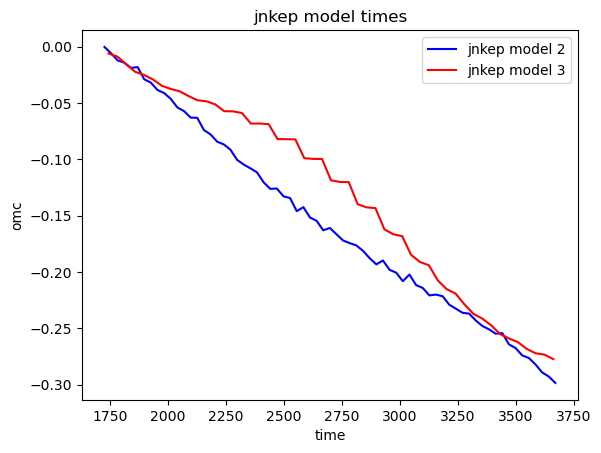

In [44]:
### plot the jnkep model
ind_jnkep_2 = np.arange(0,(len(np.array(t_jnkep_2))), 1)
ind_jnkep_3 = np.arange(0,(len(np.array(t_jnkep_3))), 1)

jnkep_ephem_time_2 = ephem(best_fit_period_2, best_fit_tc_2, ind_jnkep_2)
jnkep_ephem_time_3 = ephem(best_fit_period_3, best_fit_tc_3, ind_jnkep_3)

jnkep_omc_2 = t_jnkep_2 - jnkep_ephem_time_2
jnkep_omc_3 = t_jnkep_3 - jnkep_ephem_time_3

# plt.plot(t_jnkep_b, jnkep_omc_b, label='jnkep model b', c='g')
# plt.plot(t_jnkep_c, jnkep_omc_c, label='jnkep model c', c='r')

# Plotting
plt.plot(t_jnkep_2, jnkep_omc_2, label='jnkep model 2', linestyle='-', color='b')


plt.plot(t_jnkep_3, jnkep_omc_3, label='jnkep model 3', linestyle='-', color='r')

plt.title('jnkep model times')
plt.xlabel('time')
plt.ylabel('omc')
plt.legend()
plt.show()

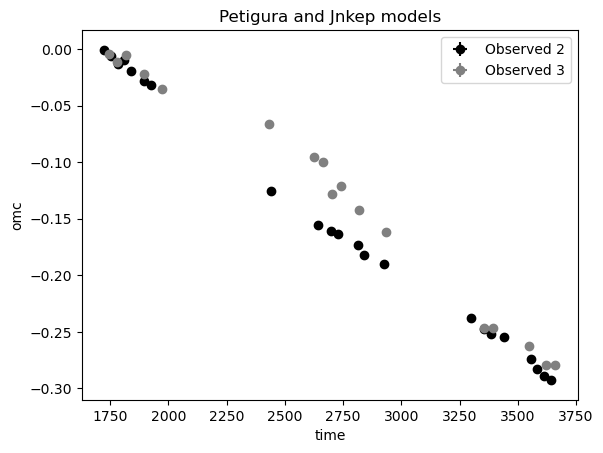

In [45]:
index_obs_2 = np.array(index_obs_2)
index_obs_3 = np.array(index_obs_3)
t_obs_2 = np.array(t_obs_2)
t_obs_3 = np.array(t_obs_3)
omc_obs_2 = t_obs_2 - ephem(best_fit_period_2, best_fit_tc_2, index_obs_2)
omc_obs_3 = t_obs_3 - ephem(best_fit_period_3, best_fit_tc_3, index_obs_3)


plt.errorbar(t_obs_2, omc_obs_2, xerr=t_obs_err_2, yerr=t_obs_err_2, marker='o', linestyle='none', label='Observed 2', c='black')
plt.errorbar(t_obs_3, omc_obs_3, xerr=t_obs_err_3, yerr=t_obs_err_3, marker='o', linestyle='none', label='Observed 3', c='grey')

plt.title('Petigura and Jnkep models')
plt.xlabel('time')
plt.ylabel('omc')
# plt.xlim(2027.88,2027.92)
# plt.xlim(1900,5500)

plt.legend()
plt.show()

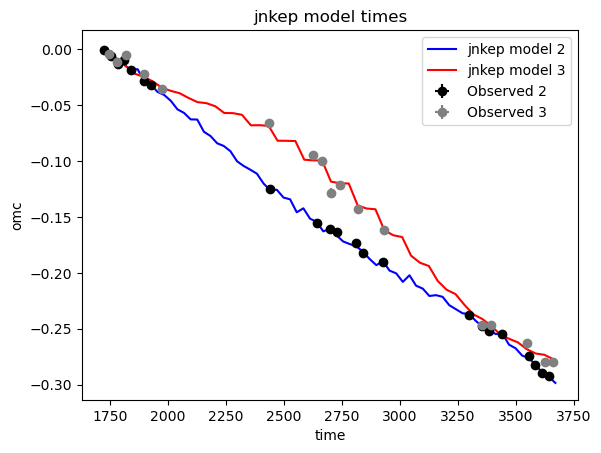

In [46]:
# Plotting
plt.plot(t_jnkep_2, jnkep_omc_2, label='jnkep model 2', linestyle='-', color='b')

plt.plot(t_jnkep_3, jnkep_omc_3, label='jnkep model 3', linestyle='-', color='r')

plt.errorbar(t_obs_2, omc_obs_2, xerr=t_obs_err_2, yerr=t_obs_err_2, marker='o', linestyle='none', label='Observed 2', c='black')
plt.errorbar(t_obs_3, omc_obs_3, xerr=t_obs_err_3, yerr=t_obs_err_3, marker='o', linestyle='none', label='Observed 3', c='grey')

plt.title('jnkep model times')
plt.xlabel('time')
plt.ylabel('omc')
plt.legend()
plt.show()

In [47]:
# Interpolate model at observed points if needed
from scipy.interpolate import interp1d

# Interpolation to match observed points
model_interp_2 = interp1d(t_jnkep_2, jnkep_omc_2, bounds_error=False, fill_value="extrapolate")
model_interp_3 = interp1d(t_jnkep_3, jnkep_omc_3, bounds_error=False, fill_value="extrapolate")

residuals_2 = omc_obs_2 - model_interp_2(t_obs_2)
residuals_3 = omc_obs_3 - model_interp_3(t_obs_3)


In [48]:
# plt.errorbar(t_obs_2, residuals_2, xerr=t_obs_err_2, yerr=t_obs_err_2,
#              marker='o', linestyle='none', label='jnkep model residuals 2', color='b')
# plt.errorbar(t_obs_3, residuals_3, xerr=t_obs_err_3, yerr=t_obs_err_3,
#              marker='s', linestyle='none', label='jnkep model residuals 3', color='r')

# plt.axhline(0, color='k', linestyle='--', linewidth=1)
# plt.title('jnkep residuals')
# plt.xlabel('time')
# plt.ylabel('Residuals (days)')
# plt.grid(True)
# plt.legend()
# plt.show()

In [49]:
## flatten and plot models too 
# Use a linear fit (degree=1) to get slope and intercept
coeffs_2 = np.polyfit(t_jnkep_2, jnkep_omc_2, 1)
slope_2 = coeffs_2[0]
print(f'2 slope for jnkep model (from linear fit): {slope_2}')
coeffs_3 = np.polyfit(t_jnkep_3, jnkep_omc_3, 1)
slope_3 = coeffs_3[0]
print(f'3 slope for jnkep model (from linear fit): {slope_3}')

2 slope for jnkep model (from linear fit): -0.00014930861344367808
3 slope for jnkep model (from linear fit): -0.00015122201896579292


In [50]:
### Fit the linear trend for b and c (using numpy.polyfit)
def apply_trend(t, y, slope):
    # Ensure t and y are NumPy arrays
    t = np.asarray(t)
    y = np.asarray(y)
    # Remove slope, pivot about the first point
    return y - slope * (t - t[0])

flat_jnkep_2 = apply_trend(t_jnkep_2, jnkep_omc_2, slope_2)
flat_obs_2 = apply_trend(t_obs_2, (omc_obs_2), slope_2)
flat_jnkep_3 = apply_trend(t_jnkep_3, jnkep_omc_3, slope_3)
flat_obs_3 = apply_trend(t_obs_3, (omc_obs_3), slope_3)

flat_obs_2 = np.array(flat_obs_2)
t_obs_err_2 = np.array(t_obs_err_2)
flat_obs_3 = np.array(flat_obs_3)
t_obs_err_3 = np.array(t_obs_err_3)

# plt.plot(t_jnkep_2, (flat_jnkep_2*24)+0.2, label='jnkep Model 2', color='b')
# plt.plot(t_jnkep_3, (flat_jnkep_3*24)-0.4, label='jnkep Model 3', color='r')
# plt.errorbar(t_obs_2, (flat_obs_2*24)+0.2, xerr=t_obs_err_2, yerr=t_obs_err_2*24, 
#              marker='o', linestyle='none', label='Jnkep Residuals 2', color='b')
# plt.errorbar(t_obs_3, (flat_obs_3*24)-0.4, xerr=t_obs_err_3, yerr=t_obs_err_3*24,
#              marker='s', linestyle='none', label='Jnkep Residuals 3', color='r')
# plt.legend()
# plt.show()


# Sine fit

In [51]:
import pickle

if bootstrap == True:
    # Load the data
    with open("1339_sine_fit.pkl", "rb") as f:
        ttv_data = pickle.load(f)

else:
    # Load the data
    with open("1339_sine_fit_no_bootstrap.pkl", "rb") as f:
        ttv_data = pickle.load(f)

# Access individual arrays
tc_lin_obs_2 = ttv_data['tc_lin_obs_2']
omc_obs_2 = ttv_data['omc_2']
# ttv_model_2 = ttv_data['ttv_model_2']
sine_residuals_2 = ttv_data["residuals_2"]
tc_err_2 = ttv_data['tc_err_2']
indices_2 = ttv_data['indices_2']

tc_lin_obs_3 = ttv_data['tc_lin_obs_3']
omc_obs_3 = ttv_data['omc_3']
# ttv_model_3 = ttv_data['ttv_model_3']
sine_residuals_3 = ttv_data["residuals_3"]
tc_err_3 = ttv_data['tc_err_3']
indices_3 = ttv_data['indices_3']

t_dense = ttv_data['t_dense']
ttv_2 = ttv_data['ttv_2']
ttv_3 = ttv_data['ttv_3']

In [52]:
# plt.errorbar(tc_lin_obs_2, sine_residuals_2, yerr=np.array(tc_err_2), fmt='o',
#              color='b', markersize=5, label="sine Residuals 2")
# plt.errorbar(tc_lin_obs_3, sine_residuals_3, yerr=np.array(tc_err_3), fmt='o',
#              color='r', markersize=5, label="sine Residuals 3")

# plt.axhline(0, color='k', linestyle='--', linewidth=1)
# plt.title('sine fit residuals')
# plt.xlabel('time')
# plt.ylabel('Residuals (days)')
# plt.grid(True)
# plt.legend()
# plt.show()


In [53]:
# plt.plot(t_dense, ttv_2*24, label='sine Model 2', color='b')
# plt.plot(t_dense, ttv_3*24, label='sine Model 3', color='r')
# plt.errorbar(tc_lin_obs_2, omc_obs_2*24, yerr=np.array(tc_err_2)*24, fmt='o',
#              color='b', label='Observed O-C (Planet 2)', markersize=5)
# plt.errorbar(tc_lin_obs_3, omc_obs_3*24, yerr=np.array(tc_err_3)*24, fmt='o',
#              color='r', label='Observed O-C (Planet 3)', markersize=5)


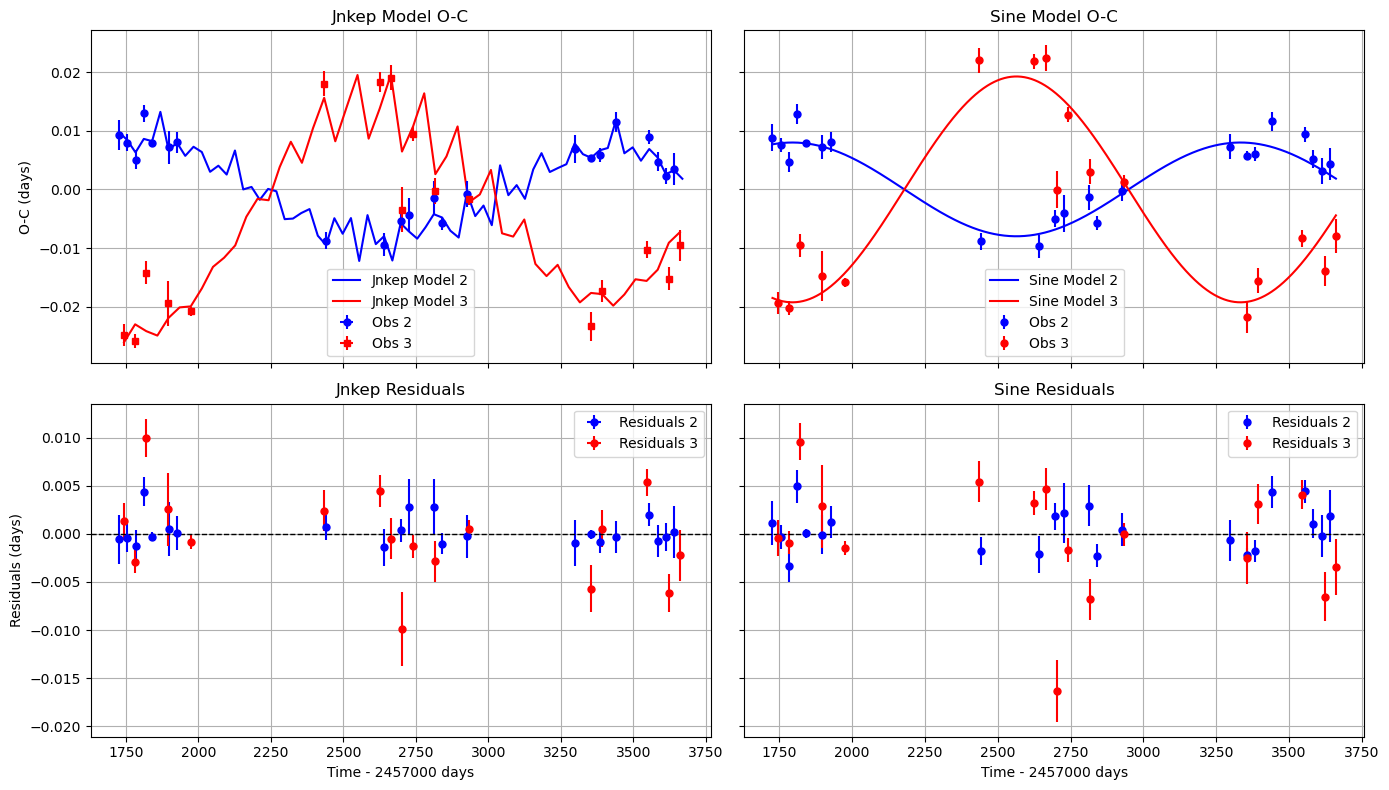

In [54]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex='col', sharey='row')


offset_2 = 0.01
offset_3 = -0.02
# --- Top Left: Jnkep Model Plot ---
axes[0, 0].plot(t_jnkep_2, (flat_jnkep_2+offset_2), label='Jnkep Model 2', color='b')
axes[0, 0].plot(t_jnkep_3, (flat_jnkep_3+offset_3), label='Jnkep Model 3', color='r')
axes[0, 0].errorbar(t_obs_2, (flat_obs_2+offset_2), xerr=t_obs_err_2, yerr=t_obs_err_2,
                   marker='o', linestyle='none', markersize=5, color='b', label='Obs 2')
axes[0, 0].errorbar(t_obs_3, (flat_obs_3+offset_3), xerr=t_obs_err_3, yerr=t_obs_err_3,
                   marker='s', linestyle='none', markersize=5, color='r', label='Obs 3')
axes[0, 0].set_title('Jnkep Model O-C')
axes[0, 0].set_ylabel('O-C (days)')
axes[0, 0].legend()
axes[0, 0].grid(True)

# --- Top Right: Sine Model Plot ---
axes[0, 1].plot(t_dense, ttv_2, label='Sine Model 2', color='b')
axes[0, 1].plot(t_dense, ttv_3, label='Sine Model 3', color='r')
axes[0, 1].errorbar(tc_lin_obs_2, omc_obs_2, yerr=np.array(tc_err_2),
                   fmt='o', color='b', markersize=5, label='Obs 2')
axes[0, 1].errorbar(tc_lin_obs_3, omc_obs_3, yerr=np.array(tc_err_3),
                   fmt='o', color='r', markersize=5, label='Obs 3')
axes[0, 1].set_title('Sine Model O-C')
axes[0, 1].grid(True)
axes[0, 1].legend()

# --- Bottom Left: Jnkep Residuals ---
axes[1, 0].errorbar(t_obs_2, residuals_2, xerr=t_obs_err_2, yerr=t_obs_err_2,
                    marker='o', linestyle='none', markersize=5, label='Residuals 2', color='b')
axes[1, 0].errorbar(t_obs_3, residuals_3, xerr=t_obs_err_3, yerr=t_obs_err_3,
                    marker='o', linestyle='none', markersize=5, label='Residuals 3', color='r')
axes[1, 0].axhline(0, color='k', linestyle='--', linewidth=1)
axes[1, 0].set_title('Jnkep Residuals')
axes[1, 0].set_xlabel(f'Time - {TESS_offset} days')
axes[1, 0].set_ylabel('Residuals (days)')
axes[1, 0].grid(True)
axes[1, 0].legend()

# --- Bottom Right: Sine Residuals ---
axes[1, 1].errorbar(tc_lin_obs_2, sine_residuals_2, yerr=np.array(tc_err_2),
                    fmt='o', color='b', markersize=5, label='Residuals 2')
axes[1, 1].errorbar(tc_lin_obs_3, sine_residuals_3, yerr=np.array(tc_err_3),
                    fmt='o', color='r', markersize=5, label='Residuals 3')
axes[1, 1].axhline(0, color='k', linestyle='--', linewidth=1)
axes[1, 1].set_title('Sine Residuals')
axes[1, 1].set_xlabel(f'Time - {TESS_offset} days')
axes[1, 1].grid(True)
axes[1, 1].legend()

plt.tight_layout()
plt.show()


In [55]:
# --- Jnkep Model RMS and Reduced Chi-Squared ---
rms_jnkep_2 = np.sqrt(np.mean(residuals_2**2))
rms_jnkep_3 = np.sqrt(np.mean(residuals_3**2))

chi2_jnkep_2 = np.sum((residuals_2 / t_obs_err_2)**2)
chi2_jnkep_3 = np.sum((residuals_3 / t_obs_err_3)**2)

# Replace these with the actual number of parameters used in your fit
num_params_jnkep = len(popt)
chi2_red_jnkep_2 = chi2_jnkep_2 / (len(residuals_2) - num_params_jnkep)
chi2_red_jnkep_3 = chi2_jnkep_3 / (len(residuals_3) - num_params_jnkep)

# --- Sine Model RMS and Reduced Chi-Squared ---
rms_sine_2 = np.sqrt(np.mean(np.array(sine_residuals_2)**2))
rms_sine_3 = np.sqrt(np.mean(np.array(sine_residuals_3)**2))

chi2_sine_2 = np.sum((np.array(sine_residuals_2) / np.array(tc_err_2))**2)
chi2_sine_3 = np.sum((np.array(sine_residuals_3) / np.array(tc_err_3))**2)

# Replace with actual number of sine model parameters
num_params_sine = 8 #t_b0, P_b, A_bc, t_c0, P_c, A_cb, P_cb, t_cb0
chi2_red_sine_2 = chi2_sine_2 / (len(sine_residuals_2) - num_params_sine)
chi2_red_sine_3 = chi2_sine_3 / (len(sine_residuals_3) - num_params_sine)


In [56]:
print(f"Jnkep Model 2: RMS = {rms_jnkep_2:.5f}, Reduced Chi² = {chi2_red_jnkep_2:.2f}")
print(f"Jnkep Model 3: RMS = {rms_jnkep_3:.5f}, Reduced Chi² = {chi2_red_jnkep_3:.2f}")
print(f"Sine Model 2: RMS = {rms_sine_2:.5f}, Reduced Chi² = {chi2_red_sine_2:.2f}")
print(f"Sine Model 3: RMS = {rms_sine_3:.5f}, Reduced Chi² = {chi2_red_sine_3:.2f}")

Jnkep Model 2: RMS = 0.00147, Reduced Chi² = 1.07
Jnkep Model 3: RMS = 0.00457, Reduced Chi² = 7.41
Sine Model 2: RMS = 0.00233, Reduced Chi² = 4.02
Sine Model 3: RMS = 0.00577, Reduced Chi² = 11.54
